# Lumbar Spinal MRI Classification Using ConvNeXt Small

Paper-ready training and evaluation of **ConvNeXt Small** for three-class lumbar-spine MRI classification.

The experiment uses a fixed stratified **70% training, 20% validation, and 10% test split**, **224 × 224** input images, **batch size 32**, **5 head-training epochs**, and up to **25 fine-tuning epochs**.


## Dataset and Experimental Design

The dataset contains **13,686 MRI images** from three classes:

- Herniated Disc
- No Stenosis
- Thecal Sac

The notebook audits every image, removes unreadable files and same-class exact duplicates, combines the original `train` and `test` directories, and creates a new fixed stratified 70/20/10 split.

Preprocessing is designed for grayscale MRI data: foreground-aware cropping, robust percentile intensity normalization, square padding, conversion to three channels, resizing to 224 × 224, mild training-only geometric and intensity augmentation, and pretrained-model normalization. Anatomical flips are not used.

## Install Dependency

In [1]:
!pip install -q timm

## Configuration

In [2]:
from pathlib import Path

SEED = 42
DATASET_ZIP = None
EXPECTED_CLASSES = ['Herniated Disc', 'No Stenosis', 'Thecal Sac']
EXPECTED_TOTAL_IMAGES = 13686

TRAIN_RATIO = 0.70
VAL_RATIO = 0.20
TEST_RATIO = 0.10

INPUT_SIZE = 224
BATCH_SIZE = 32
HEAD_EPOCHS = 5
FINE_TUNE_EPOCHS = 25

HEAD_LR = 3e-4
BACKBONE_LR = 1e-5
FINE_TUNE_HEAD_LR = 1e-4
WEIGHT_DECAY = 1e-4
DROPOUT = 0.40
LABEL_SMOOTHING = 0.05
PATIENCE = 8
MIN_DELTA = 1e-4

REMOVE_EXACT_DUPLICATES = True
RESUME_IF_AVAILABLE = True
EXPERIMENT_ID = 'lumbar_mri_convnext_small_224_bs32_h5_ft25_v1'

OUTPUT_DIR = Path('/kaggle/working') / EXPERIMENT_ID
EXTRACT_DIR = OUTPUT_DIR / 'extracted_dataset'
CHECKPOINT_DIR = OUTPUT_DIR / 'checkpoints'
FIGURE_DIR = OUTPUT_DIR / 'paper_figures'
TABLE_DIR = OUTPUT_DIR / 'tables'

MODEL_SPECS = {
    'ConvNeXtSmall': {
        'timm_name': 'convnext_small.fb_in22k_ft_in1k',
    },
}

MODELS_TO_RUN = list(MODEL_SPECS)

## Imports and Reproducibility

In [3]:
import gc
import hashlib
import json
import math
import os
import random
import shutil
import time
import warnings
import zipfile
from concurrent.futures import ThreadPoolExecutor
from contextlib import nullcontext

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import timm
import torch
import torch.nn as nn
from PIL import Image, ImageFile
from IPython.display import display
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms
from torchvision.transforms import InterpolationMode
from tqdm.auto import tqdm

warnings.filterwarnings('ignore')
ImageFile.LOAD_TRUNCATED_IMAGES = True

for path in [OUTPUT_DIR, EXTRACT_DIR, CHECKPOINT_DIR, FIGURE_DIR, TABLE_DIR]:
    path.mkdir(parents=True, exist_ok=True)

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

try:
    torch.set_float32_matmul_precision('high')
except Exception:
    pass

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_AMP = DEVICE.type == 'cuda'
NUM_WORKERS = min(4, os.cpu_count() or 2)
PIN_MEMORY = DEVICE.type == 'cuda'

print(f'Device: {DEVICE}')
print(f'PyTorch: {torch.__version__}')
print(f'timm: {timm.__version__}')

Device: cuda
PyTorch: 2.10.0+cu128
timm: 1.0.26


## Dataset Discovery

In [4]:
IMAGE_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff', '.webp'}
SEARCH_ROOTS = [Path('/kaggle/input'), Path('/mnt/data')]
DATASET_KEYWORDS = ('lumbar', 'lumber', 'spinal', 'stenosis')


def zip_score(path):
    name = path.name.lower()
    keyword_score = sum(keyword in name for keyword in DATASET_KEYWORDS)
    return keyword_score * 10_000_000 + path.stat().st_size


def discover_zip():
    if DATASET_ZIP is not None:
        path = Path(DATASET_ZIP)
        if not path.exists():
            raise FileNotFoundError(f'DATASET_ZIP does not exist: {path}')
        return path

    candidates = []
    for root in SEARCH_ROOTS:
        if root.exists():
            candidates.extend(root.rglob('*.zip'))

    candidates = [
        path for path in candidates
        if any(keyword in path.name.lower() for keyword in DATASET_KEYWORDS)
    ]
    return max(candidates, key=zip_score) if candidates else None


def class_image_folders(root):
    folders = []
    for current, dirs, _ in os.walk(root):
        current_path = Path(current)
        if current_path.name in EXPECTED_CLASSES:
            has_images = any(
                path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS
                for path in current_path.iterdir()
            )
            if has_images:
                folders.append(current_path)
            dirs[:] = []
    return folders


def discover_image_root():
    archive = discover_zip()
    if archive is not None:
        marker = EXTRACT_DIR / '.extracted'
        signature = f'{archive}:{archive.stat().st_size}'
        if not marker.exists() or marker.read_text().strip() != signature:
            if EXTRACT_DIR.exists():
                shutil.rmtree(EXTRACT_DIR)
            EXTRACT_DIR.mkdir(parents=True, exist_ok=True)
            with zipfile.ZipFile(archive) as zipped:
                zipped.extractall(EXTRACT_DIR)
            marker.write_text(signature)
        return EXTRACT_DIR, archive

    for root in SEARCH_ROOTS:
        if root.exists() and class_image_folders(root):
            return root, None

    raise FileNotFoundError('The Lumbar Spinal MRI dataset was not found.')


DATA_ROOT, ARCHIVE_PATH = discover_image_root()
CLASS_FOLDERS = class_image_folders(DATA_ROOT)
found_classes = sorted({folder.name for folder in CLASS_FOLDERS})

if found_classes != sorted(EXPECTED_CLASSES):
    raise ValueError(f'Expected {EXPECTED_CLASSES}, but found {found_classes}')

print(f'Archive: {ARCHIVE_PATH}')
print(f'Data root: {DATA_ROOT}')
print(f'Class folders: {len(CLASS_FOLDERS)}')

Archive: None
Data root: /kaggle/input
Class folders: 6


## Dataset Audit and Duplicate Control

In [5]:
def infer_original_split(path):
    lowered = [part.lower() for part in Path(path).parts]
    for split_name in ['train', 'validation', 'valid', 'val', 'test']:
        if split_name in lowered:
            return split_name
    return 'unspecified'


def inspect_image(path):
    try:
        with open(path, 'rb') as file:
            content = file.read()

        digest = hashlib.sha256(content).hexdigest()

        with Image.open(path) as image:
            width, height = image.size
            mode = image.mode
            image.verify()

        return str(path), True, digest, width, height, mode, ''
    except Exception as exc:
        return str(path), False, '', np.nan, np.nan, '', str(exc)


records = []
for folder in sorted(CLASS_FOLDERS, key=lambda path: (path.name, str(path))):
    for path in sorted(folder.iterdir()):
        if path.is_file() and path.suffix.lower() in IMAGE_EXTENSIONS:
            records.append({
                'path': str(path),
                'class_name': folder.name,
                'original_split': infer_original_split(path),
            })

raw_df = pd.DataFrame(records)
if raw_df.empty:
    raise RuntimeError('No images were found.')

with ThreadPoolExecutor(max_workers=max(2, NUM_WORKERS * 2)) as executor:
    audit_rows = list(tqdm(
        executor.map(inspect_image, raw_df['path']),
        total=len(raw_df),
        desc='Auditing images',
    ))

audit_df = pd.DataFrame(
    audit_rows,
    columns=['path', 'valid', 'sha256', 'width', 'height', 'mode', 'error'],
)

raw_df = raw_df.merge(audit_df, on='path', how='left')
valid_df = raw_df[raw_df['valid']].copy()
invalid_df = raw_df[~raw_df['valid']].copy()
invalid_df.to_csv(TABLE_DIR / 'invalid_images.csv', index=False)

cross_class_groups = (
    valid_df.groupby('sha256')['class_name']
    .nunique()
    .loc[lambda values: values > 1]
)

if len(cross_class_groups):
    raise RuntimeError('Identical images were found under different class labels.')

before_counts = valid_df['class_name'].value_counts().reindex(EXPECTED_CLASSES)

if REMOVE_EXACT_DUPLICATES:
    cleaned_df = valid_df.drop_duplicates('sha256', keep='first').copy()
else:
    cleaned_df = valid_df.copy()

cleaned_df = cleaned_df.sort_values(['class_name', 'path']).reset_index(drop=True)
after_counts = cleaned_df['class_name'].value_counts().reindex(EXPECTED_CLASSES)
duplicate_count = len(valid_df) - len(cleaned_df)

class_names = sorted(cleaned_df['class_name'].unique())
class_to_index = {name: index for index, name in enumerate(class_names)}
cleaned_df['label'] = cleaned_df['class_name'].map(class_to_index).astype(int)

audit_summary = pd.DataFrame({
    'Before deduplication': before_counts,
    'After deduplication': after_counts,
})

original_split_summary = pd.crosstab(
    valid_df['original_split'],
    valid_df['class_name'],
).reindex(columns=class_names, fill_value=0)

audit_summary.to_csv(TABLE_DIR / 'dataset_audit_summary.csv')
original_split_summary.to_csv(TABLE_DIR / 'original_split_distribution.csv')
cleaned_df.to_csv(TABLE_DIR / 'cleaned_dataset_manifest.csv', index=False)

print(f'Original images: {len(raw_df):,}')
print(f'Invalid images: {len(invalid_df):,}')
print(f'Exact duplicate copies removed: {duplicate_count:,}')
print(f'Retained images: {len(cleaned_df):,}')

if len(raw_df) != EXPECTED_TOTAL_IMAGES:
    print(f'Warning: expected {EXPECTED_TOTAL_IMAGES:,} images, found {len(raw_df):,}.')

display(audit_summary)
display(original_split_summary)

Auditing images:   0%|          | 0/13686 [00:00<?, ?it/s]

Original images: 13,686
Invalid images: 0
Exact duplicate copies removed: 650
Retained images: 13,036


,Before deduplication,After deduplication
class_name,,
Herniated Disc,4281,4215
No Stenosis,4659,4400
Thecal Sac,4746,4421


class_name,Herniated Disc,No Stenosis,Thecal Sac
original_split,,,
test,1218,1507,13
train,3063,3152,4733


## Stratified 70/20/10 Split

In [6]:
if not math.isclose(TRAIN_RATIO + VAL_RATIO + TEST_RATIO, 1.0):
    raise ValueError('TRAIN_RATIO + VAL_RATIO + TEST_RATIO must equal 1.0')

train_df, remaining_df = train_test_split(
    cleaned_df,
    test_size=VAL_RATIO + TEST_RATIO,
    stratify=cleaned_df['label'],
    random_state=SEED,
)

val_df, test_df = train_test_split(
    remaining_df,
    test_size=TEST_RATIO / (VAL_RATIO + TEST_RATIO),
    stratify=remaining_df['label'],
    random_state=SEED,
)

train_df = train_df.sort_values(['label', 'path']).reset_index(drop=True)
val_df = val_df.sort_values(['label', 'path']).reset_index(drop=True)
test_df = test_df.sort_values(['label', 'path']).reset_index(drop=True)

for name, frame in [('train', train_df), ('validation', val_df), ('test', test_df)]:
    frame.to_csv(TABLE_DIR / f'{name}_split.csv', index=False)

train_hashes = set(train_df['sha256'])
val_hashes = set(val_df['sha256'])
test_hashes = set(test_df['sha256'])

if train_hashes & val_hashes or train_hashes & test_hashes or val_hashes & test_hashes:
    raise RuntimeError('Exact-copy leakage was detected between splits.')

split_table = pd.DataFrame({
    'Training': train_df['class_name'].value_counts().reindex(class_names),
    'Validation': val_df['class_name'].value_counts().reindex(class_names),
    'Test': test_df['class_name'].value_counts().reindex(class_names),
}).astype(int)

split_table.loc['Total'] = split_table.sum()
split_table.to_csv(TABLE_DIR / 'class_distribution_after_split.csv')

display(split_table)
print(f'Training: {len(train_df):,} ({len(train_df) / len(cleaned_df):.2%})')
print(f'Validation: {len(val_df):,} ({len(val_df) / len(cleaned_df):.2%})')
print(f'Test: {len(test_df):,} ({len(test_df) / len(cleaned_df):.2%})')

,Training,Validation,Test
class_name,,,
Herniated Disc,2950,843,422
No Stenosis,3080,880,440
Thecal Sac,3095,884,442
Total,9125,2607,1304


Training: 9,125 (70.00%)
Validation: 2,607 (20.00%)
Test: 1,304 (10.00%)


## MRI Preprocessing and Data Pipeline

In [7]:
def save_figure(fig, stem):
    fig.savefig(
        FIGURE_DIR / f'{stem}.png',
        dpi=400,
        bbox_inches='tight',
        facecolor='white',
    )
    fig.savefig(
        FIGURE_DIR / f'{stem}.pdf',
        bbox_inches='tight',
        facecolor='white',
    )


class MRIPreprocess:
    def __init__(self, threshold=10, lower_percentile=1.0, upper_percentile=99.0, padding=0.04):
        self.threshold = threshold
        self.lower_percentile = lower_percentile
        self.upper_percentile = upper_percentile
        self.padding = padding

    def __call__(self, image):
        gray = np.asarray(image.convert('L'), dtype=np.uint8)

        foreground_mask = gray > self.threshold
        if foreground_mask.any():
            rows, columns = np.where(foreground_mask)
            top, bottom = rows.min(), rows.max() + 1
            left, right = columns.min(), columns.max() + 1

            vertical_padding = max(2, int((bottom - top) * self.padding))
            horizontal_padding = max(2, int((right - left) * self.padding))

            top = max(0, top - vertical_padding)
            bottom = min(gray.shape[0], bottom + vertical_padding)
            left = max(0, left - horizontal_padding)
            right = min(gray.shape[1], right + horizontal_padding)

            gray = gray[top:bottom, left:right]

        foreground = gray[gray > self.threshold]
        if foreground.size > 10:
            lower, upper = np.percentile(
                foreground,
                [self.lower_percentile, self.upper_percentile],
            )
            if upper > lower:
                gray = np.clip(
                    (gray.astype(np.float32) - lower) * 255.0 / (upper - lower),
                    0,
                    255,
                ).astype(np.uint8)

        height, width = gray.shape
        side = max(height, width)
        canvas = np.zeros((side, side), dtype=np.uint8)
        top = (side - height) // 2
        left = (side - width) // 2
        canvas[top:top + height, left:left + width] = gray

        return Image.fromarray(canvas, mode='L').convert('RGB')


class MRIFrameDataset(Dataset):
    def __init__(self, frame, transform):
        self.frame = frame.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, index):
        row = self.frame.iloc[index]
        with Image.open(row['path']) as image:
            image = image.copy()
        return self.transform(image), int(row['label']), row['path']


def seed_worker(worker_id):
    worker_seed = SEED + worker_id
    random.seed(worker_seed)
    np.random.seed(worker_seed)


def make_transforms(mean, std):
    deterministic_preprocess = MRIPreprocess()

    train_transform = transforms.Compose([
        deterministic_preprocess,
        transforms.Resize(
            (INPUT_SIZE, INPUT_SIZE),
            interpolation=InterpolationMode.BICUBIC,
            antialias=True,
        ),
        transforms.RandomAffine(
            degrees=6,
            translate=(0.03, 0.03),
            scale=(0.97, 1.03),
            interpolation=InterpolationMode.BILINEAR,
            fill=0,
        ),
        transforms.RandomApply([
            transforms.ColorJitter(brightness=0.05, contrast=0.08),
        ], p=0.50),
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std),
    ])

    eval_transform = transforms.Compose([
        deterministic_preprocess,
        transforms.Resize(
            (INPUT_SIZE, INPUT_SIZE),
            interpolation=InterpolationMode.BICUBIC,
            antialias=True,
        ),
        transforms.ToTensor(),
        transforms.Normalize(mean=mean, std=std),
    ])

    return train_transform, eval_transform


def make_loaders(mean, std):
    train_transform, eval_transform = make_transforms(mean, std)
    generator = torch.Generator().manual_seed(SEED)

    common = {
        'num_workers': NUM_WORKERS,
        'pin_memory': PIN_MEMORY,
        'persistent_workers': NUM_WORKERS > 0,
        'worker_init_fn': seed_worker,
    }

    train_loader = DataLoader(
        MRIFrameDataset(train_df, train_transform),
        batch_size=BATCH_SIZE,
        shuffle=True,
        generator=generator,
        **common,
    )

    val_loader = DataLoader(
        MRIFrameDataset(val_df, eval_transform),
        batch_size=BATCH_SIZE,
        shuffle=False,
        **common,
    )

    test_loader = DataLoader(
        MRIFrameDataset(test_df, eval_transform),
        batch_size=BATCH_SIZE,
        shuffle=False,
        **common,
    )

    return train_loader, val_loader, test_loader


weights = compute_class_weight(
    class_weight='balanced',
    classes=np.arange(len(class_names)),
    y=train_df['label'].to_numpy(),
)

class_weights = torch.tensor(weights, dtype=torch.float32, device=DEVICE)

class_weight_table = pd.DataFrame({
    'Class': class_names,
    'Weight': weights,
})

class_weight_table.to_csv(TABLE_DIR / 'class_weights.csv', index=False)
display(class_weight_table)

,Class,Weight
0,Herniated Disc,1.031073
1,No Stenosis,0.987554
2,Thecal Sac,0.982768


## Dataset and Preprocessing Figures

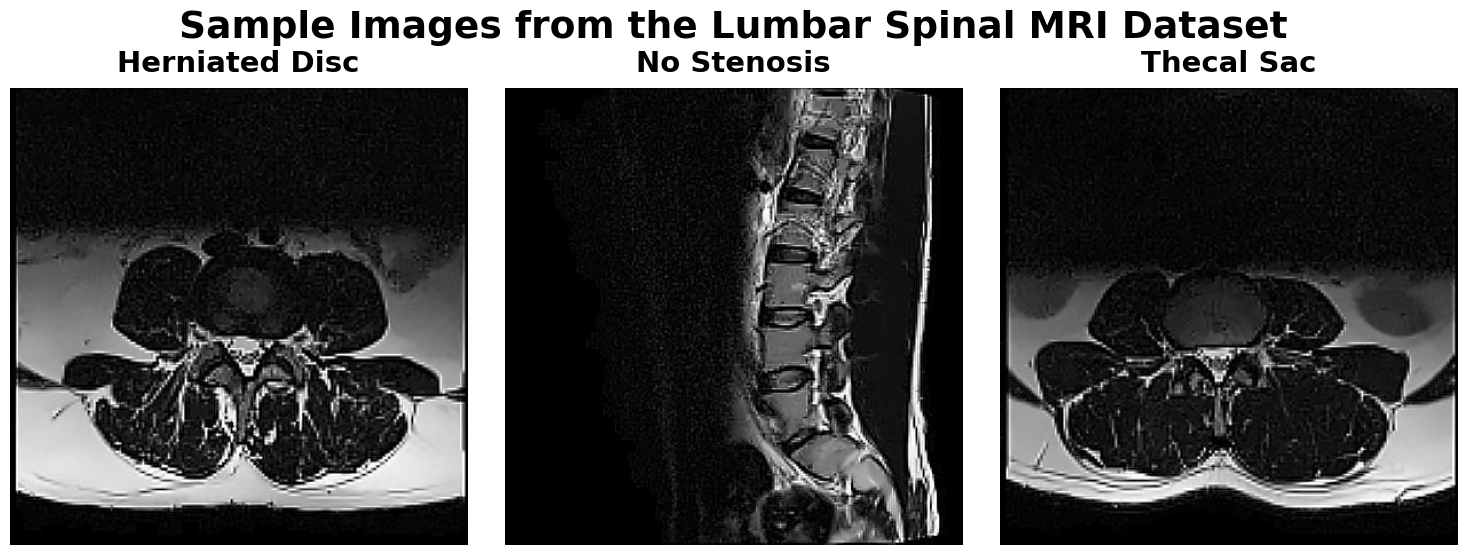

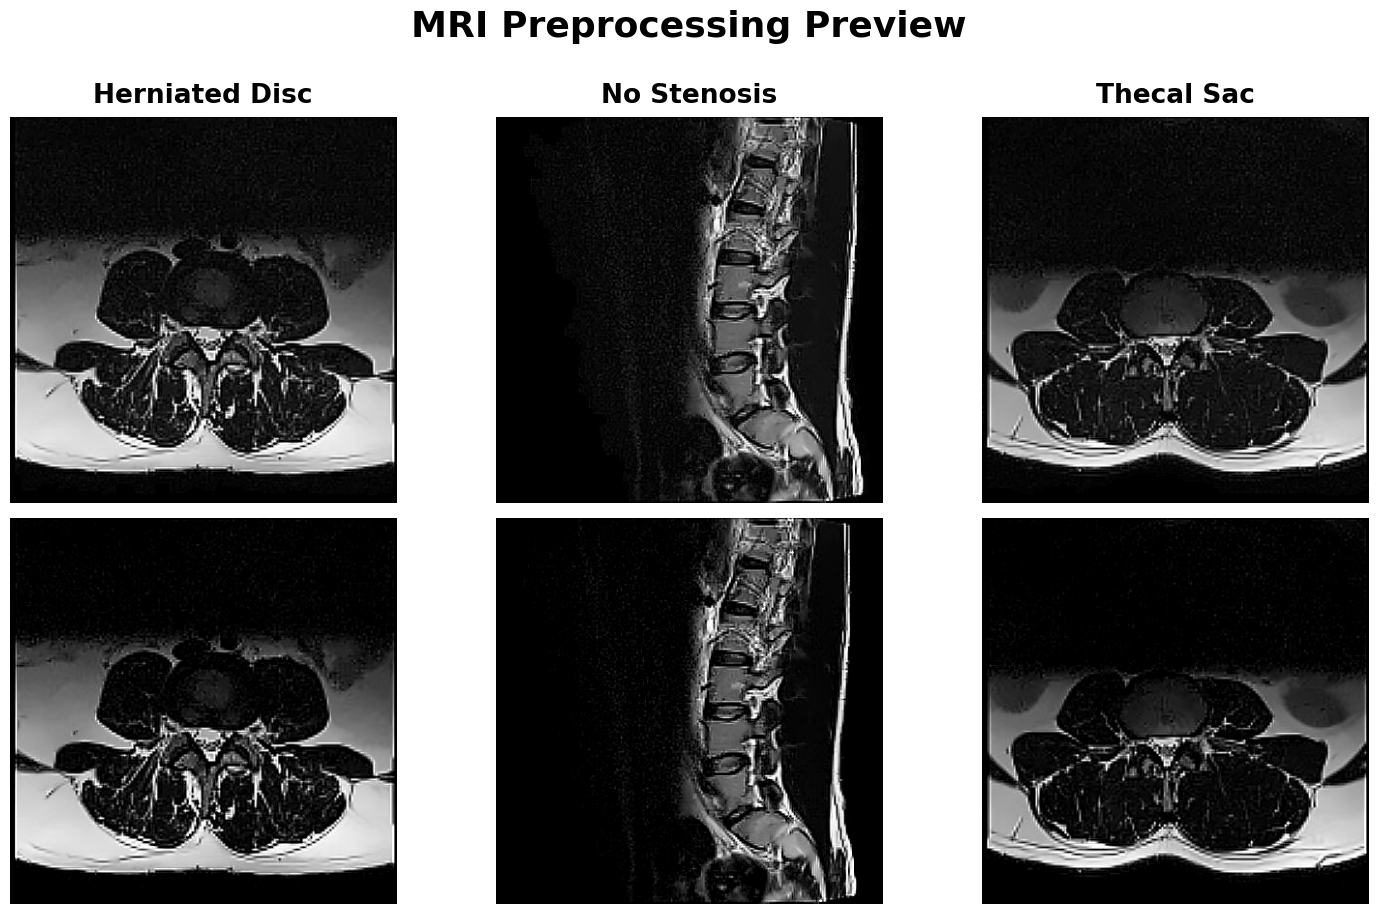

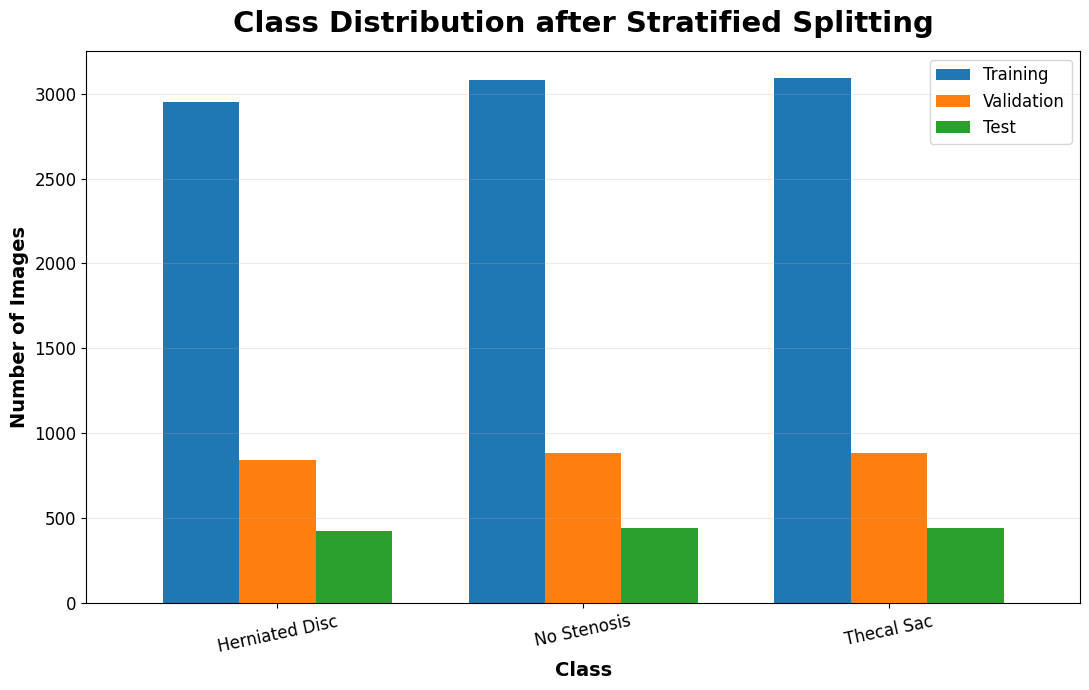

In [8]:
sample_rows = (
    cleaned_df.groupby('class_name', sort=False)
    .sample(n=1, random_state=SEED)
    .set_index('class_name')
    .reindex(class_names)
)

fig, axes = plt.subplots(1, len(class_names), figsize=(15, 5.4))
for axis, class_name in zip(axes, class_names):
    with Image.open(sample_rows.loc[class_name, 'path']) as image:
        axis.imshow(image.convert('L'), cmap='gray')
    axis.set_title(class_name, fontsize=21, fontweight='bold', pad=12)
    axis.axis('off')

fig.suptitle(
    'Sample Images from the Lumbar Spinal MRI Dataset',
    fontsize=27,
    fontweight='bold',
    y=1.02,
)
fig.tight_layout()
save_figure(fig, 'sample_images_per_class')
plt.show()

preprocess = MRIPreprocess()
fig, axes = plt.subplots(2, len(class_names), figsize=(15, 9))

for column, class_name in enumerate(class_names):
    with Image.open(sample_rows.loc[class_name, 'path']) as image:
        original = image.convert('L')
        processed = preprocess(image)

    axes[0, column].imshow(original, cmap='gray')
    axes[0, column].set_title(class_name, fontsize=19, fontweight='bold', pad=10)
    axes[0, column].axis('off')

    axes[1, column].imshow(processed)
    axes[1, column].axis('off')

axes[0, 0].set_ylabel('Original', fontsize=18, fontweight='bold')
axes[1, 0].set_ylabel('Preprocessed', fontsize=18, fontweight='bold')

fig.suptitle(
    'MRI Preprocessing Preview',
    fontsize=26,
    fontweight='bold',
    y=1.01,
)
fig.tight_layout()
save_figure(fig, 'mri_preprocessing_preview')
plt.show()

plot_counts = split_table.drop(index='Total')
fig, axis = plt.subplots(figsize=(11, 7))
plot_counts.plot(kind='bar', ax=axis, width=0.75)
axis.set_title(
    'Class Distribution after Stratified Splitting',
    fontsize=21,
    fontweight='bold',
    pad=14,
)
axis.set_xlabel('Class', fontsize=14, fontweight='bold')
axis.set_ylabel('Number of Images', fontsize=14, fontweight='bold')
axis.tick_params(axis='x', labelrotation=12, labelsize=12)
axis.tick_params(axis='y', labelsize=12)
axis.grid(axis='y', alpha=0.25)
axis.legend(fontsize=12)
fig.tight_layout()
save_figure(fig, 'class_distribution_after_split')
plt.show()

## ConvNeXt Small Transfer-Learning Model

In [9]:
class TransferClassifier(nn.Module):
    def __init__(self, timm_name, num_classes, pretrained=True):
        super().__init__()
        self.backbone = timm.create_model(
            timm_name,
            pretrained=pretrained,
            num_classes=0,
            global_pool='avg',
        )
        feature_count = int(
        self.backbone.head_hidden_size
        if hasattr(self.backbone, "head_hidden_size")
        else self.backbone.num_features
        )
        self.classifier = nn.Sequential(
            nn.Dropout(DROPOUT),
            nn.Linear(feature_count, num_classes),
        )

    def forward(self, inputs):
        features = self.backbone(inputs)
        return self.classifier(features)


def build_model(model_label, pretrained=True):
    timm_name = MODEL_SPECS[model_label]['timm_name']
    config = timm.get_pretrained_cfg(timm_name)

    if config is None:
        raise RuntimeError(f'No pretrained configuration was found for {timm_name}')

    try:
        model = TransferClassifier(
            timm_name,
            len(class_names),
            pretrained=pretrained,
        )
    except Exception as exc:
        if pretrained:
            raise RuntimeError(
                'Pretrained weights could not be loaded. Enable Kaggle Internet and rerun.'
            ) from exc
        raise

    mean = tuple(config.mean)
    std = tuple(config.std)

    return model, timm_name, mean, std


model_overview = pd.DataFrame([
    {
        'Model': model_label,
        'timm identifier': MODEL_SPECS[model_label]['timm_name'],
        'Input size': f'{INPUT_SIZE} × {INPUT_SIZE}',
        'Batch size': BATCH_SIZE,
    }
    for model_label in MODELS_TO_RUN
])

display(model_overview)

,Model,timm identifier,Input size,Batch size
0,ConvNeXtSmall,convnext_small.fb_in22k_ft_in1k,224 × 224,32


## Training Utilities

In [10]:
def autocast_context(training=True):
    if USE_AMP and training:
        return torch.autocast(
            device_type='cuda',
            dtype=torch.float16,
        )
    return nullcontext()


def make_scaler():
    try:
        return torch.amp.GradScaler('cuda', enabled=USE_AMP)
    except Exception:
        return torch.cuda.amp.GradScaler(enabled=USE_AMP)

def freeze_batchnorm(model):
    for module in model.backbone.modules():
        if isinstance(module, nn.modules.batchnorm._BatchNorm):
            module.eval()
            for parameter in module.parameters():
                parameter.requires_grad = False

def configure_stage(model, stage):
    if stage == 'head':
        for parameter in model.backbone.parameters():
            parameter.requires_grad = False
        for parameter in model.classifier.parameters():
            parameter.requires_grad = True
    else:
        for parameter in model.parameters():
            parameter.requires_grad = True


def make_optimizer(model, stage):
    if stage == 'head':
        return torch.optim.AdamW(
            model.classifier.parameters(),
            lr=HEAD_LR,
            weight_decay=WEIGHT_DECAY,
        )

    return torch.optim.AdamW([
        {
            'params': model.backbone.parameters(),
            'lr': BACKBONE_LR,
        },
        {
            'params': model.classifier.parameters(),
            'lr': FINE_TUNE_HEAD_LR,
        },
    ], weight_decay=WEIGHT_DECAY)


def run_epoch(model, loader, criterion, optimizer=None, scaler=None, stage='fine_tune'):
    training = optimizer is not None
    model.train(training)

    if training and stage == 'head':
        model.backbone.eval()

    if training and stage == 'fine_tune':
        freeze_batchnorm(model)

    running_loss = 0.0
    labels_all = []
    predictions_all = []

    progress = tqdm(
        loader,
        leave=False,
        desc='Training' if training else 'Validation',
    )

    for images, labels, _ in progress:
        images = images.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        if training:
            optimizer.zero_grad(set_to_none=True)

        with torch.set_grad_enabled(training):
            with autocast_context(training):
                logits = model(images)
                loss = criterion(logits, labels)

            if not torch.isfinite(logits).all():
                raise RuntimeError(
                    f'Non-finite logits detected during '
                    f'{"training" if training else "validation"}.'
                ) 

            if not torch.isfinite(loss):
                raise RuntimeError(
                    f'Non-finite loss detected during '
                    f'{"training" if training else "validation"}.'
                )

            if training:
                scaler.scale(loss).backward()
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
                scaler.step(optimizer)
                scaler.update()

        running_loss += loss.item() * labels.size(0)
        labels_all.extend(labels.detach().cpu().numpy())
        predictions_all.extend(logits.argmax(dim=1).detach().cpu().numpy())
        progress.set_postfix(loss=f'{loss.item():.4f}')

    epoch_loss = running_loss / len(loader.dataset)
    epoch_accuracy = accuracy_score(labels_all, predictions_all)
    epoch_f1 = f1_score(
        labels_all,
        predictions_all,
        average='macro',
        zero_division=0,
    )

    return epoch_loss, epoch_accuracy, epoch_f1


def save_history_plot(history, model_label):
    frame = pd.DataFrame(history)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5.8))

    axes[0].plot(
        frame['epoch'],
        frame['train_loss'],
        marker='o',
        linewidth=2,
        label='Train Loss',
    )
    axes[0].plot(
        frame['epoch'],
        frame['val_loss'],
        marker='o',
        linewidth=2,
        label='Validation Loss',
    )
    axes[0].set_title('Training and Validation Loss', fontsize=18, fontweight='bold')
    axes[0].set_xlabel('Epoch', fontsize=13, fontweight='bold')
    axes[0].set_ylabel('Loss', fontsize=13, fontweight='bold')
    axes[0].grid(alpha=0.25)
    axes[0].legend(fontsize=11)

    axes[1].plot(
        frame['epoch'],
        frame['train_accuracy'],
        marker='o',
        linewidth=2,
        label='Train Accuracy',
    )
    axes[1].plot(
        frame['epoch'],
        frame['val_accuracy'],
        marker='o',
        linewidth=2,
        label='Validation Accuracy',
    )
    axes[1].set_title('Training and Validation Accuracy', fontsize=18, fontweight='bold')
    axes[1].set_xlabel('Epoch', fontsize=13, fontweight='bold')
    axes[1].set_ylabel('Accuracy', fontsize=13, fontweight='bold')
    axes[1].set_ylim(0, 1.02)
    axes[1].grid(alpha=0.25)
    axes[1].legend(fontsize=11)

    fine_tune_epochs = frame.loc[frame['stage'] == 'fine_tune', 'epoch']
    if len(fine_tune_epochs):
        fine_tune_start = fine_tune_epochs.min()
        for axis in axes:
            axis.axvline(
                fine_tune_start - 0.5,
                linestyle='--',
                linewidth=1.5,
                label='Fine-tuning starts',
            )

    fig.suptitle(
        f'{model_label}: Training History',
        fontsize=22,
        fontweight='bold',
        y=1.02,
    )
    fig.tight_layout()
    save_figure(fig, f'training_history_{model_label.lower()}')
    plt.show()


def load_checkpoint(path, device):
    try:
        return torch.load(path, map_location=device, weights_only=False)
    except TypeError:
        return torch.load(path, map_location=device)


def train_model(model_label):
    checkpoint_path = CHECKPOINT_DIR / f'{model_label.lower()}_best.pth'
    history_path = TABLE_DIR / f'{model_label.lower()}_history.csv'
    metadata_path = TABLE_DIR / f'{model_label.lower()}_training.json'

    model, timm_name, mean, std = build_model(model_label, pretrained=True)
    model = model.to(DEVICE)

    train_loader, val_loader, test_loader = make_loaders(mean, std)
    criterion = nn.CrossEntropyLoss(
        weight=class_weights,
        label_smoothing=LABEL_SMOOTHING,
    )
    scaler = make_scaler()

    history = []
    best_score = -np.inf
    best_val_loss = np.inf
    best_epoch = 0
    global_epoch = 0
    training_start = time.perf_counter()

    stages = [
        ('head', HEAD_EPOCHS),
        ('fine_tune', FINE_TUNE_EPOCHS),
    ]

    for stage, stage_epochs in stages:
        if stage == 'fine_tune' and checkpoint_path.exists():
            checkpoint = load_checkpoint(checkpoint_path, DEVICE)
            model.load_state_dict(checkpoint['model_state_dict'])

        configure_stage(model, stage)
        optimizer = make_optimizer(model, stage)
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer,
            mode='max',
            factor=0.5,
            patience=2,
            min_lr=1e-7,
        )
        patience_count = 0

        for _ in range(stage_epochs):
            global_epoch += 1

            train_loss, train_accuracy, train_f1 = run_epoch(
                model,
                train_loader,
                criterion,
                optimizer,
                scaler,
                stage,
            )

            val_loss, val_accuracy, val_f1 = run_epoch(
                model,
                val_loader,
                criterion,
            )

            scheduler.step(val_f1)
            learning_rates = [group['lr'] for group in optimizer.param_groups]

            history.append({
                'epoch': global_epoch,
                'stage': stage,
                'train_loss': train_loss,
                'val_loss': val_loss,
                'train_accuracy': train_accuracy,
                'val_accuracy': val_accuracy,
                'train_f1': train_f1,
                'val_f1': val_f1,
                'learning_rate': max(learning_rates),
            })

            improved = (
                val_f1 > best_score + MIN_DELTA
                or (
                    abs(val_f1 - best_score) <= MIN_DELTA
                    and val_loss < best_val_loss
                )
            )

            if improved:
                best_score = val_f1
                best_val_loss = val_loss
                best_epoch = global_epoch
                patience_count = 0

                torch.save({
                    'experiment_id': EXPERIMENT_ID,
                    'model_state_dict': model.state_dict(),
                    'model_label': model_label,
                    'timm_name': timm_name,
                    'class_names': class_names,
                    'mean': mean,
                    'std': std,
                    'input_size': INPUT_SIZE,
                    'batch_size': BATCH_SIZE,
                    'best_epoch': best_epoch,
                    'best_val_f1': float(best_score),
                    'best_val_loss': float(best_val_loss),
                }, checkpoint_path)
            else:
                patience_count += 1

            print(
                f'{model_label} | {stage} | epoch {global_epoch:02d} | '
                f'train loss {train_loss:.4f} | val loss {val_loss:.4f} | '
                f'train acc {train_accuracy:.4f} | val acc {val_accuracy:.4f}'
            )

            if stage == 'fine_tune' and patience_count >= PATIENCE:
                print(f'Early stopping at epoch {global_epoch}.')
                break

    training_seconds = time.perf_counter() - training_start
    best_checkpoint = load_checkpoint(checkpoint_path, DEVICE)
    model.load_state_dict(best_checkpoint['model_state_dict'])

    history_frame = pd.DataFrame(history)
    history_frame.to_csv(history_path, index=False)

    metadata = {
        'experiment_id': EXPERIMENT_ID,
        'model': model_label,
        'timm_name': timm_name,
        'input_size': INPUT_SIZE,
        'batch_size': BATCH_SIZE,
        'head_epochs': HEAD_EPOCHS,
        'fine_tune_epochs': FINE_TUNE_EPOCHS,
        'best_epoch': best_epoch,
        'best_val_f1': float(best_score),
        'best_val_loss': float(best_val_loss),
        'training_seconds': float(training_seconds),
    }

    metadata_path.write_text(json.dumps(metadata, indent=2))
    save_history_plot(history, model_label)

    return model, val_loader, test_loader, metadata

## Evaluation Utilities

In [11]:
def predict_classes(model, loader):
    model.eval()
    labels_all = []
    predictions_all = []
    paths_all = []
    start = time.perf_counter()

    with torch.no_grad():
        for images, labels, paths in tqdm(loader, leave=False, desc='Predicting'):
            images = images.to(DEVICE, non_blocking=True)

            with autocast_context(False):
                logits = model(images)

            predictions = logits.argmax(dim=1).cpu().numpy()
            labels_all.append(labels.numpy())
            predictions_all.append(predictions)
            paths_all.extend(paths)

    elapsed = time.perf_counter() - start

    return (
        np.concatenate(labels_all),
        np.concatenate(predictions_all),
        np.asarray(paths_all),
        elapsed,
    )


def calculate_metrics(y_true, y_pred):
    return {
        'accuracy': float(accuracy_score(y_true, y_pred)),
        'precision': float(precision_score(
            y_true,
            y_pred,
            average='macro',
            zero_division=0,
        )),
        'recall': float(recall_score(
            y_true,
            y_pred,
            average='macro',
            zero_division=0,
        )),
        'f1_score': float(f1_score(
            y_true,
            y_pred,
            average='macro',
            zero_division=0,
        )),
    }


def plot_confusion_matrix(matrix, model_label):
    fig, axis = plt.subplots(figsize=(8.8, 7.5))
    image = axis.imshow(matrix, interpolation='nearest', cmap='Blues')
    colorbar = fig.colorbar(image, ax=axis, fraction=0.046, pad=0.04)
    colorbar.ax.tick_params(labelsize=12)

    threshold = matrix.max() / 2 if matrix.size else 0

    for row in range(matrix.shape[0]):
        for column in range(matrix.shape[1]):
            value = int(matrix[row, column])
            axis.text(
                column,
                row,
                str(value),
                ha='center',
                va='center',
                fontsize=21,
                fontweight='bold',
                color='white' if value > threshold else 'black',
            )

    axis.set_xticks(np.arange(len(class_names)))
    axis.set_yticks(np.arange(len(class_names)))
    axis.set_xticklabels(
        class_names,
        rotation=18,
        ha='right',
        fontsize=14,
        fontweight='bold',
    )
    axis.set_yticklabels(
        class_names,
        fontsize=14,
        fontweight='bold',
    )
    axis.set_xlabel(
        'Predicted Label',
        fontsize=17,
        fontweight='bold',
        labelpad=12,
    )
    axis.set_ylabel(
        'True Label',
        fontsize=17,
        fontweight='bold',
        labelpad=12,
    )
    axis.set_title(
        f'{model_label} Confusion Matrix',
        fontsize=23,
        fontweight='bold',
        pad=16,
    )

    fig.tight_layout()
    save_figure(fig, f'confusion_matrix_{model_label.lower()}')
    plt.show()


def save_evaluation(model_label, model, test_loader, metadata):
    y_true, y_pred, paths, inference_seconds = predict_classes(
        model,
        test_loader,
    )

    metrics = calculate_metrics(y_true, y_pred)
    metrics.update({
        'experiment_id': EXPERIMENT_ID,
        'model': model_label,
        'input_size': INPUT_SIZE,
        'batch_size': BATCH_SIZE,
        'best_epoch': metadata['best_epoch'],
        'training_seconds': metadata['training_seconds'],
        'inference_ms_per_image': float(
            inference_seconds * 1000 / len(y_true)
        ),
    })

    report = classification_report(
        y_true,
        y_pred,
        labels=np.arange(len(class_names)),
        target_names=class_names,
        output_dict=True,
        zero_division=0,
    )

    pd.DataFrame(report).T.to_csv(
        TABLE_DIR / f'{model_label.lower()}_classification_report.csv'
    )

    pd.DataFrame({
        'path': paths,
        'true_label': [class_names[index] for index in y_true],
        'predicted_label': [class_names[index] for index in y_pred],
    }).to_csv(
        TABLE_DIR / f'{model_label.lower()}_test_predictions.csv',
        index=False,
    )

    (TABLE_DIR / f'{model_label.lower()}_metrics.json').write_text(
        json.dumps(metrics, indent=2)
    )

    matrix = confusion_matrix(
        y_true,
        y_pred,
        labels=np.arange(len(class_names)),
    )

    plot_confusion_matrix(matrix, model_label)

    return metrics


def completed_metrics(model_label):
    checkpoint_path = CHECKPOINT_DIR / f'{model_label.lower()}_best.pth'
    metrics_path = TABLE_DIR / f'{model_label.lower()}_metrics.json'

    if not RESUME_IF_AVAILABLE:
        return None

    if checkpoint_path.exists() and metrics_path.exists():
        metrics = json.loads(metrics_path.read_text())
        if metrics.get('experiment_id') == EXPERIMENT_ID:
            return metrics

    return None

## Train and Evaluate ConvNeXt Small


ConvNeXtSmall


model.safetensors:   0%|          | 0.00/201M [00:00<?, ?B/s]

Training:   0%|          | 0/286 [00:00<?, ?it/s]

Validation:   0%|          | 0/82 [00:00<?, ?it/s]

ConvNeXtSmall | head | epoch 01 | train loss 1.2042 | val loss 1.0946 | train acc 0.3543 | val acc 0.3993


...

Validation:   0%|          | 0/82 [00:00<?, ?it/s]

ConvNeXtSmall | fine_tune | epoch 29 | train loss 0.1836 | val loss 0.4633 | train acc 0.9962 | val acc 0.8711


Training:   0%|          | 0/286 [00:00<?, ?it/s]

Validation:   0%|          | 0/82 [00:00<?, ?it/s]

ConvNeXtSmall | fine_tune | epoch 30 | train loss 0.1771 | val loss 0.4237 | train acc 0.9985 | val acc 0.8934


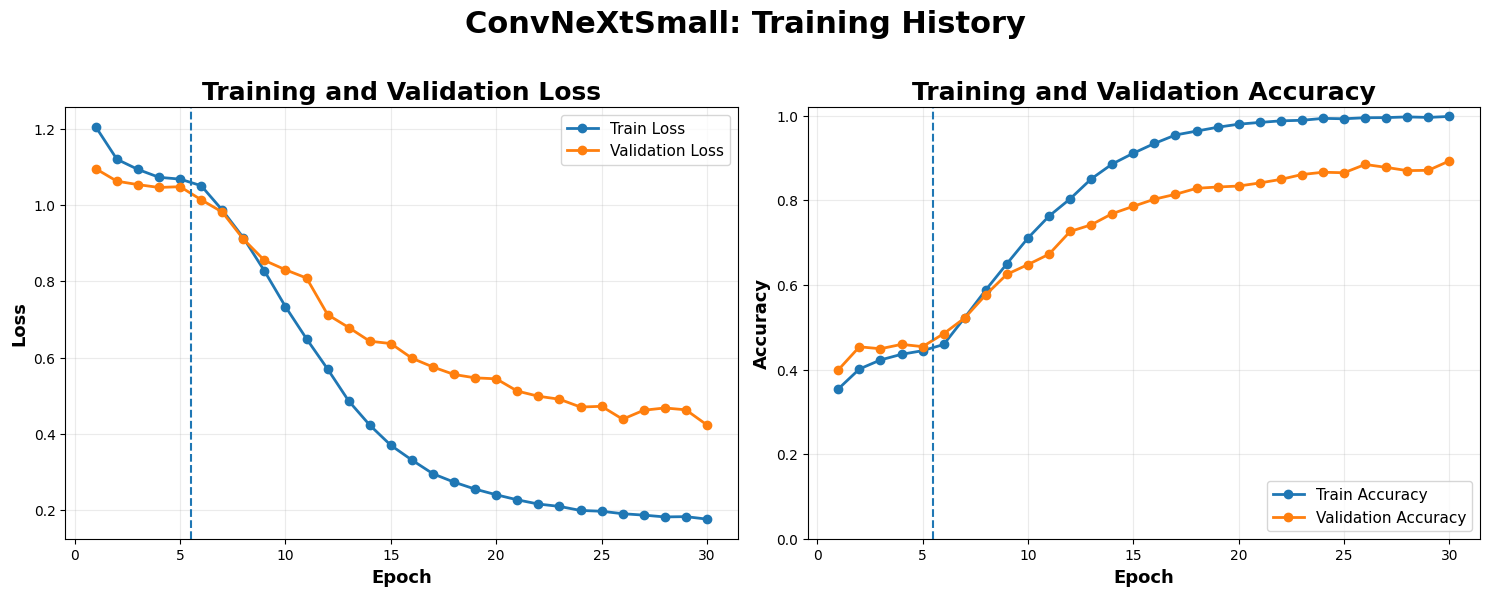

Predicting:   0%|          | 0/41 [00:00<?, ?it/s]

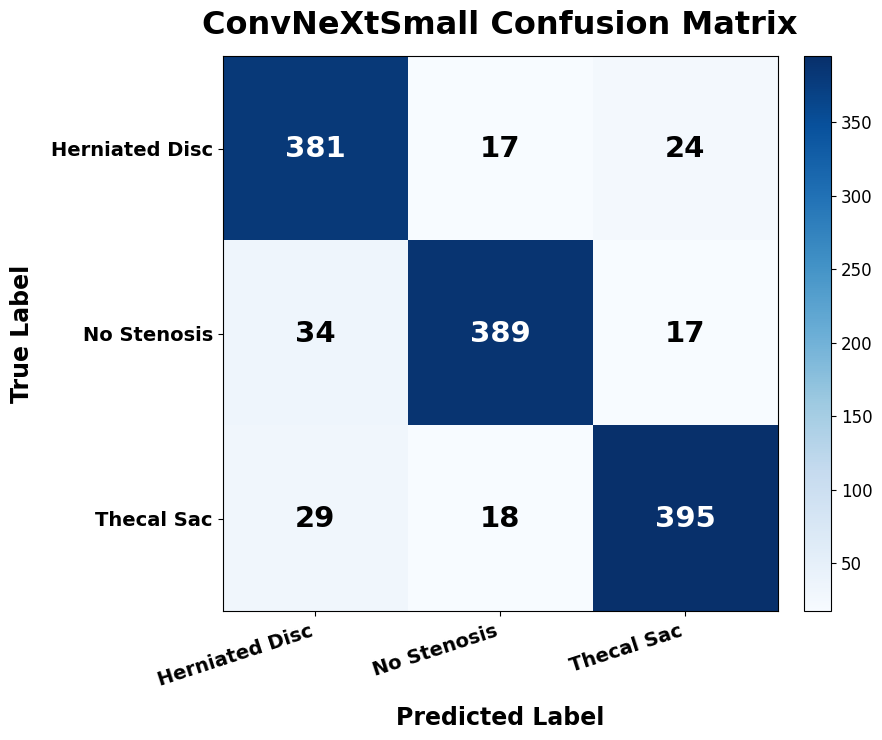

,Accuracy,Precision,Recall,F1 Score
Model,,,,
ConvNeXtSmall,0.893405,0.893841,0.893533,0.893381


In [12]:
all_metrics = []

for model_label in MODELS_TO_RUN:
    print('\n' + '=' * 88)
    print(model_label)
    print('=' * 88)

    saved = completed_metrics(model_label)

    if saved is not None:
        print('Loaded completed result for the current experiment configuration.')
        all_metrics.append(saved)
        continue

    model, val_loader, test_loader, metadata = train_model(model_label)
    metrics = save_evaluation(
        model_label,
        model,
        test_loader,
        metadata,
    )

    all_metrics.append(metrics)

    display(pd.DataFrame([{
        'Model': model_label,
        'Accuracy': metrics['accuracy'],
        'Precision': metrics['precision'],
        'Recall': metrics['recall'],
        'F1 Score': metrics['f1_score'],
    }]).set_index('Model'))

    model.to('cpu')
    del model, val_loader, test_loader
    gc.collect()

    if DEVICE.type == 'cuda':
        torch.cuda.empty_cache()

## Export Paper Assets

In [13]:
run_summary = {
    'dataset': 'Lumbar Spinal MRI Dataset',
    'archive': str(ARCHIVE_PATH),
    'classes': class_names,
    'original_images': int(len(raw_df)),
    'retained_unique_images': int(len(cleaned_df)),
    'training_images': int(len(train_df)),
    'validation_images': int(len(val_df)),
    'test_images': int(len(test_df)),
    'split': {
        'train': TRAIN_RATIO,
        'validation': VAL_RATIO,
        'test': TEST_RATIO,
    },
    'input_size': INPUT_SIZE,
    'batch_size': BATCH_SIZE,
    'head_epochs': HEAD_EPOCHS,
    'fine_tune_epochs': FINE_TUNE_EPOCHS,
    'seed': SEED,
    'models': MODEL_SPECS,
    'preprocessing': [
        'foreground-aware crop',
        'robust 1st-99th percentile intensity normalization',
        'square padding',
        'three-channel conversion',
        '224x224 bicubic resizing',
        'mild training-only affine and intensity augmentation',
        'pretrained-model normalization',
    ],
    'patient_level_split_available': False,
}

(OUTPUT_DIR / 'run_summary.json').write_text(
    json.dumps(run_summary, indent=2)
)

readme = '\n'.join([
    'Lumbar Spinal MRI Classification Study',
    '',
    f'Original images: {len(raw_df):,}',
    f'Unique retained images: {len(cleaned_df):,}',
    f'Training images: {len(train_df):,}',
    f'Validation images: {len(val_df):,}',
    f'Test images: {len(test_df):,}',
    f"Classes: {', '.join(class_names)}",
    f"Models: {', '.join(MODELS_TO_RUN)}",
    f'Input size: {INPUT_SIZE} x {INPUT_SIZE}',
    f'Batch size: {BATCH_SIZE}',
    f'Head training epochs: {HEAD_EPOCHS}',
    f'Fine-tuning epochs: {FINE_TUNE_EPOCHS}',
    '',
    'The dataset does not expose patient identifiers. The requested split is image-level. Exact duplicate images are removed before splitting.',
])

(OUTPUT_DIR / 'README.txt').write_text(readme)

paper_zip = Path('/kaggle/working/lumbar_spinal_mri_convnext_small_paper_assets.zip')

with zipfile.ZipFile(
    paper_zip,
    'w',
    compression=zipfile.ZIP_DEFLATED,
) as archive:
    for folder in [FIGURE_DIR, TABLE_DIR]:
        for path in folder.rglob('*'):
            if path.is_file():
                archive.write(path, path.relative_to(OUTPUT_DIR))

    archive.write(
        OUTPUT_DIR / 'README.txt',
        'README.txt',
    )
    archive.write(
        OUTPUT_DIR / 'run_summary.json',
        'run_summary.json',
    )

print(f'Figures: {FIGURE_DIR}')
print(f'Tables: {TABLE_DIR}')
print(f'Checkpoints: {CHECKPOINT_DIR}')
print(f'Paper assets ZIP: {paper_zip}')

Figures: /kaggle/working/lumbar_mri_convnext_small_224_bs32_h5_ft25_v1/paper_figures
Tables: /kaggle/working/lumbar_mri_convnext_small_224_bs32_h5_ft25_v1/tables
Checkpoints: /kaggle/working/lumbar_mri_convnext_small_224_bs32_h5_ft25_v1/checkpoints
Paper assets ZIP: /kaggle/working/lumbar_spinal_mri_convnext_small_paper_assets.zip
